In [1]:
import numpy as np
import pandas as pd

In [2]:
ds = pd.read_csv("HousingData.csv")
ds = ds.dropna()
ds.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7


In [3]:
X = ds.drop(["MEDV"], axis=1)
Y = ds.MEDV
print(X)
print(Y)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
5    0.02985   0.0   2.18   0.0  0.458  6.430  58.7  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
499  0.17783   0.0   9.69   0.0  0.585  5.569  73.5  2.3999    6  391   
500  0.22438   0.0   9.69   0.0  0.585  6.027  79.7  2.4982    6  391   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(315, 13) (315,)
(79, 13) (79,)


In [5]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
model = linear_model.LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [6]:
Y_pred = model.predict(X_test)

In [8]:
print("ce:",model.coef_)
print("ic:",model.intercept_)
print("mse:",mean_squared_error(Y_test,Y_pred))
print("r2:",r2_score(Y_test,Y_pred))

ce: [-6.07677461e-02  4.93011029e-02  7.48158366e-02  2.04076672e+00
 -1.94860313e+01  4.37972673e+00 -1.79247012e-02 -1.59388902e+00
  2.73190743e-01 -1.45848309e-02 -9.90173014e-01  1.09846219e-02
 -3.98834439e-01]
ic: 34.42232773410763
mse: 16.555714270005357
r2: 0.7666786195888313


In [9]:
Y_test

37     21.0
182    37.9
237    31.5
404     8.5
65     23.5
       ... 
71     21.7
495    23.1
481    23.7
134    15.6
105    19.5
Name: MEDV, Length: 79, dtype: float64

In [10]:
Y_pred

array([22.89416107, 33.25798773, 32.18409127,  9.42101278, 30.28548016,
       24.99294186, 17.23522266, 27.81449737, 17.51287586, 26.98139412,
       19.33638386, 32.34075675, 19.45444689, 12.62957466, 33.57180285,
        7.0799777 , 21.16342968, 19.63216111, 25.9050558 , 25.1486566 ,
       25.72562222, 24.91513445, 28.24614851, 24.69744537, 31.88404024,
       24.61318233, 30.82701203, 24.06582007, 26.63411305, 21.89535739,
       15.2405829 , 20.22185203, 26.65019964, 22.98680575, 28.62443158,
       13.59553638, 16.0212681 , 20.22867105, 14.27790594, 32.18549962,
       30.6906583 , 24.05462668, 29.09839259, 21.7866587 , 39.75266058,
       20.94316053, 19.83799276, 19.67129166, 18.99820522, 17.71932634,
       32.83754809, 18.94623727, 14.15138276, 18.24483754, 20.31760218,
       10.54484508, 12.95235508, 29.02473389, 18.23535438, 17.59705806,
       20.61613418, 15.91586345, 41.35179053, 14.90905274, 32.15579848,
       35.62330306, 34.82562717, 24.42283504, 15.11433255, 18.20

<Axes: xlabel='MEDV'>

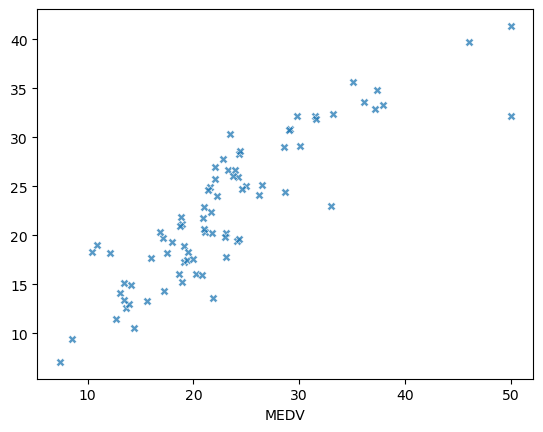

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=Y_test,y=Y_pred,marker="X",alpha=0.75)

<Axes: xlabel='MEDV'>

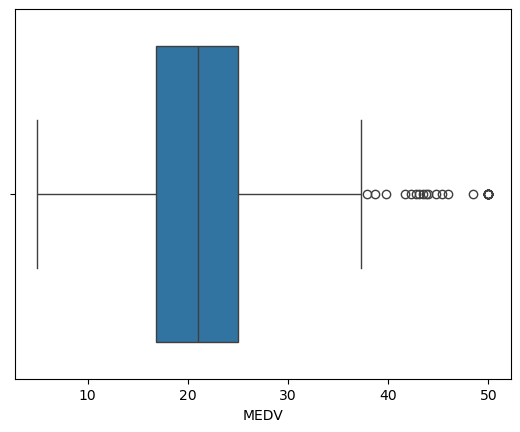

In [28]:
sns.boxplot(x=ds["MEDV"])

In [29]:
ds.shape

(394, 14)

In [27]:
q_low = ds["MEDV"].quantile(0.01)
q_high = ds["MEDV"].quantile(0.99)
q_filt = ds[(ds["MEDV"] < q_high) & (ds["MEDV"] > q_low)]
q_filt.shape

(378, 14)

<Axes: xlabel='MEDV'>

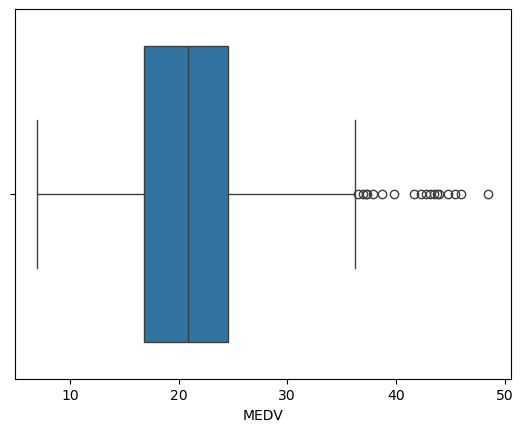

In [26]:
sns.boxplot(x=q_filt["MEDV"])

In [30]:
q1 = ds["MEDV"].quantile(0.25)
q3 = ds["MEDV"].quantile(0.75)
IQR = q3 - q1
lb = q1 - 1.5 * IQR
ub = q3 + 1.5 * IQR
iqrf = ds[(ds["MEDV"] >= lb) & (ds["MEDV"] <= ub)]

<Axes: xlabel='MEDV'>

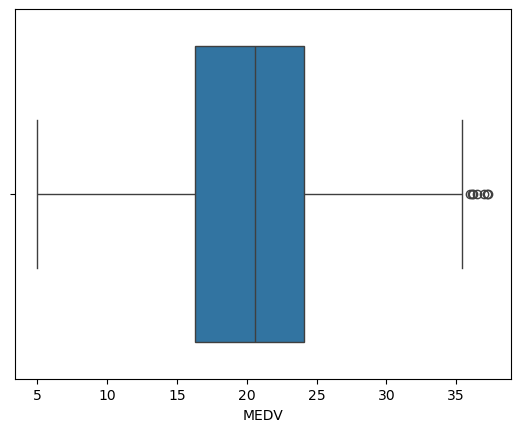

In [31]:
sns.boxplot(x=iqrf["MEDV"])